# Test for Activation Pattern Generation

This notebook tests the `generate_activation_pattern` and `convert_pattern_to_time_series` functions from `utilities.data_utils`.

1.  It generates a random source activation pattern.
2.  It converts this pattern into a time series.
3.  It plots the resulting time series of active source counts.

In [9]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
import torch

# Assuming the notebook is in the 'code' directory, and 'utilities' is a sub-directory.
from utilities.data_utils import generate_activation_pattern, convert_pattern_to_time_series

In [ ]:
# --- Parameters for the test ---
total_duration = 60.0  # seconds
sampling_frequency = 100  # Hz (for the time series representation, not audio)
max_sources = 4
time_between_events = (2.0, 5.0)  # seconds
initial_noise_only_duration = (2.0, 5.0)  # seconds
activations_only = False
source_ids = [f"S{i}" for i in range(1, max_sources + 1)]

# 1. Generate the activation pattern
activation_pattern = generate_activation_pattern(
    source_ids=source_ids,
    max_sources=max_sources,
    total_duration=total_duration,
    time_between_events=time_between_events,
    initial_noise_only_duration=initial_noise_only_duration,
    activations_only=activations_only
)

print("--- Generated Activation Pattern (Events) ---")
for event in activation_pattern:
    print(f"Time: {event['time']:.2f}s, Type: Source {event['source_id']} {'Activation' if event['type']==1 else 'Deactivation'}, Active sources: {event['num_sources']} {event['active_sources']}")

--- Generated Activation Pattern (Events) ---
Time: 2.83s, Type: Source S4 Activation, Active sources: 1 ['S4']
Time: 6.09s, Type: Source S3 Activation, Active sources: 2 ['S4', 'S3']
Time: 9.65s, Type: Source S2 Activation, Active sources: 3 ['S4', 'S3', 'S2']
Time: 13.43s, Type: Source S4 Deactivation, Active sources: 2 ['S3', 'S2']
Time: 15.77s, Type: Source S1 Activation, Active sources: 3 ['S3', 'S2', 'S1']
Time: 20.45s, Type: Source S1 Deactivation, Active sources: 2 ['S3', 'S2']
Time: 23.78s, Type: Source S1 Activation, Active sources: 3 ['S3', 'S2', 'S1']
Time: 28.14s, Type: Source S2 Deactivation, Active sources: 2 ['S3', 'S1']
Time: 31.52s, Type: Source S3 Deactivation, Active sources: 1 ['S1']
Time: 33.58s, Type: Source S1 Deactivation, Active sources: 0 []
Time: 36.45s, Type: Source S2 Activation, Active sources: 1 ['S2']
Time: 38.65s, Type: Source S2 Deactivation, Active sources: 0 []
Time: 40.89s, Type: Source S3 Activation, Active sources: 1 ['S3']
Time: 42.94s, Type: So

In [11]:
# 2. Convert the pattern to a time series
time_series = convert_pattern_to_time_series(
    activation_pattern=activation_pattern,
    total_duration=total_duration,
    sampling_frequency=sampling_frequency,
)

print(f"\n--- Time Series ---")
print(f"Shape: {time_series.shape}")
print(f"Duration: {time_series.shape[0] / sampling_frequency}s")


--- Time Series ---
Shape: torch.Size([6000])
Duration: 60.0s


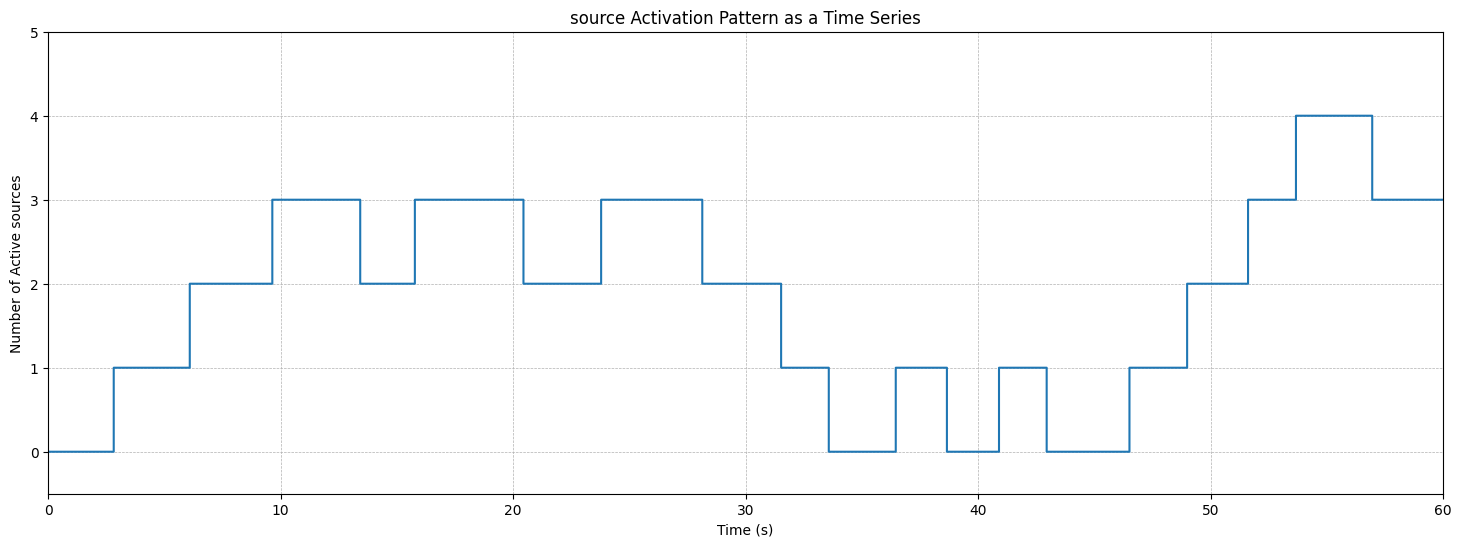

In [12]:
# 3. Plot the time series
time_vector = np.linspace(0, total_duration, time_series.shape[0])

plt.figure(figsize=(18, 6))
plt.step(time_vector, time_series.numpy(), where='post')
plt.title("source Activation Pattern as a Time Series")
plt.xlabel("Time (s)")
plt.ylabel("Number of Active sources")
plt.yticks(range(max_sources + 2))
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(bottom=-0.5)
plt.xlim(left=0, right=total_duration)
plt.show()

--- Event Transition Statistics ---
Transition 0 -> 1: 4 occurrences
Transition 1 -> 2: 2 occurrences
Transition 2 -> 3: 4 occurrences
Transition 3 -> 4: 1 occurrences
Transition 4 -> 3: 1 occurrences
Transition 3 -> 2: 3 occurrences
Transition 2 -> 1: 1 occurrences
Transition 1 -> 0: 3 occurrences

--- Source Number Distribution (over time) ---
0 active sources: 19.17% of the time
1 active sources: 20.08% of the time
2 active sources: 25.42% of the time
3 active sources: 29.87% of the time
4 active sources: 5.47% of the time


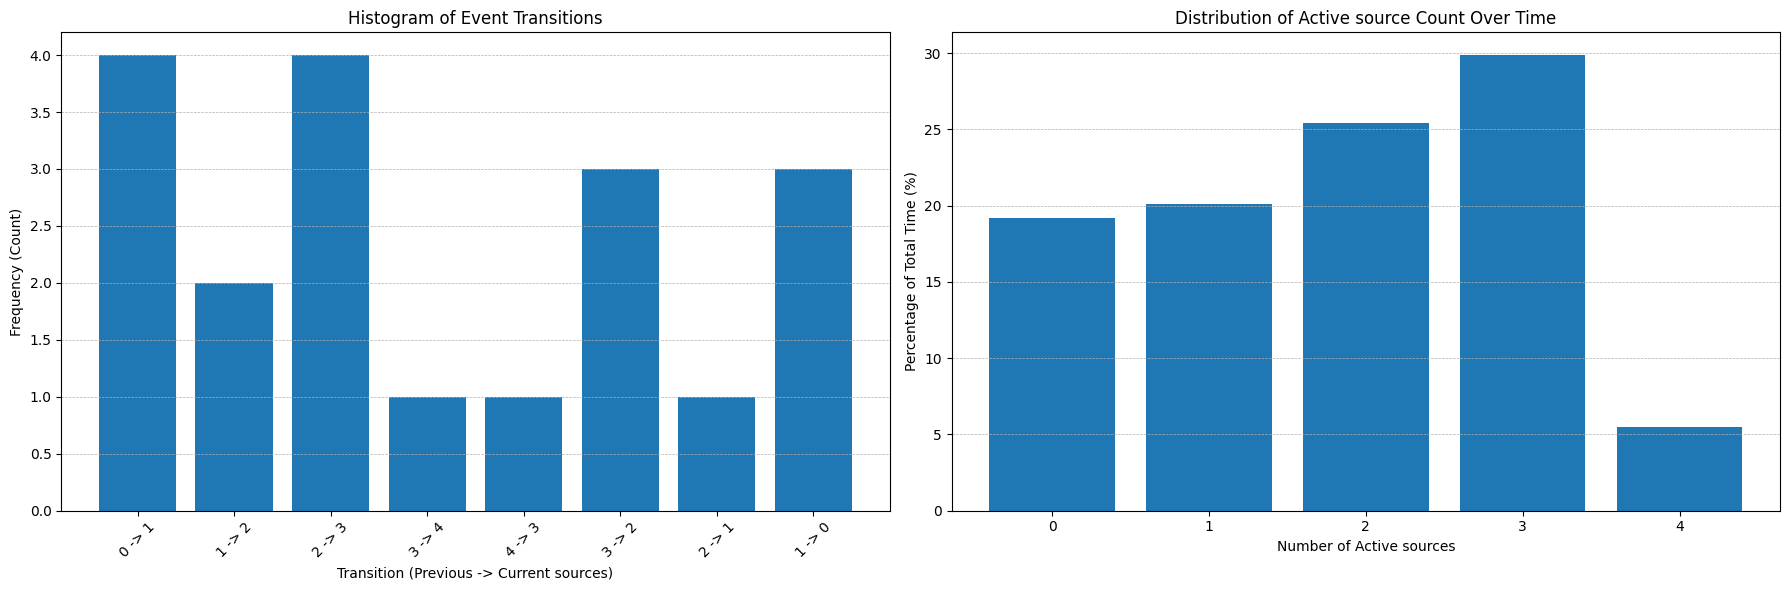

In [13]:
# 4. Calculate and plot statistics
from collections import Counter

# --- Event Transition Statistics ---
transitions = []
prev_num_sources = 0
for event in activation_pattern:
    current_num_sources = event['num_sources']
    transitions.append(f"{prev_num_sources} -> {current_num_sources}")
    prev_num_sources = current_num_sources

transition_counts = Counter(transitions)

# Define the custom sort order for transitions
activation_transitions = [f"{i} -> {i+1}" for i in range(max_sources)]
deactivation_transitions = [f"{i} -> {i-1}" for i in range(max_sources, 0, -1)]
custom_sort_order = activation_transitions + deactivation_transitions

# Sort the collected transitions based on the custom order
sorted_transition_items = sorted(
    transition_counts.items(),
    key=lambda item: custom_sort_order.index(item[0]) if item[0] in custom_sort_order else -1
)

print("--- Event Transition Statistics ---")
for transition, count in sorted_transition_items:
    print(f"Transition {transition}: {count} occurrences")

# --- Source Number Distribution Statistics ---
source_counts = torch.bincount(time_series)
source_distribution = source_counts.float() / time_series.numel()
print("\n--- Source Number Distribution (over time) ---")
for i, percentage in enumerate(source_distribution):
    print(f"{i} active sources: {percentage:.2%} of the time")

# --- Plotting Histograms ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Subplot 1: Histogram of event transitions
if sorted_transition_items:
    labels, values = zip(*sorted_transition_items)
    ax1.bar(labels, values)
else:
    labels, values = [], []
ax1.set_title("Histogram of Event Transitions")
ax1.set_xlabel("Transition (Previous -> Current sources)")
ax1.set_ylabel("Frequency (Count)")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', linewidth=0.5)

# Subplot 2: Histogram of source number distribution
num_sources = np.arange(len(source_distribution))
ax2.bar(num_sources, source_distribution.numpy() * 100)
ax2.set_title("Distribution of Active source Count Over Time")
ax2.set_xlabel("Number of Active sources")
ax2.set_ylabel("Percentage of Total Time (%)")
ax2.set_xticks(num_sources)
ax2.grid(axis='y', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

Running simulation for 10000 activation patterns...
Simulation finished.

--- Aggregated Event Transition Statistics ---
Transition 0 -> 1: 33632 occurrences
Transition 1 -> 2: 25230 occurrences
Transition 2 -> 3: 19031 occurrences
Transition 3 -> 4: 15505 occurrences
Transition 4 -> 3: 14221 occurrences
Transition 3 -> 2: 15276 occurrences
Transition 2 -> 1: 18975 occurrences
Transition 1 -> 0: 24882 occurrences

--- Aggregated Source Number Distribution (over time) ---
0 active sources: 19.96% of the time
1 active sources: 29.89% of the time
2 active sources: 22.83% of the time
3 active sources: 18.65% of the time
4 active sources: 8.67% of the time


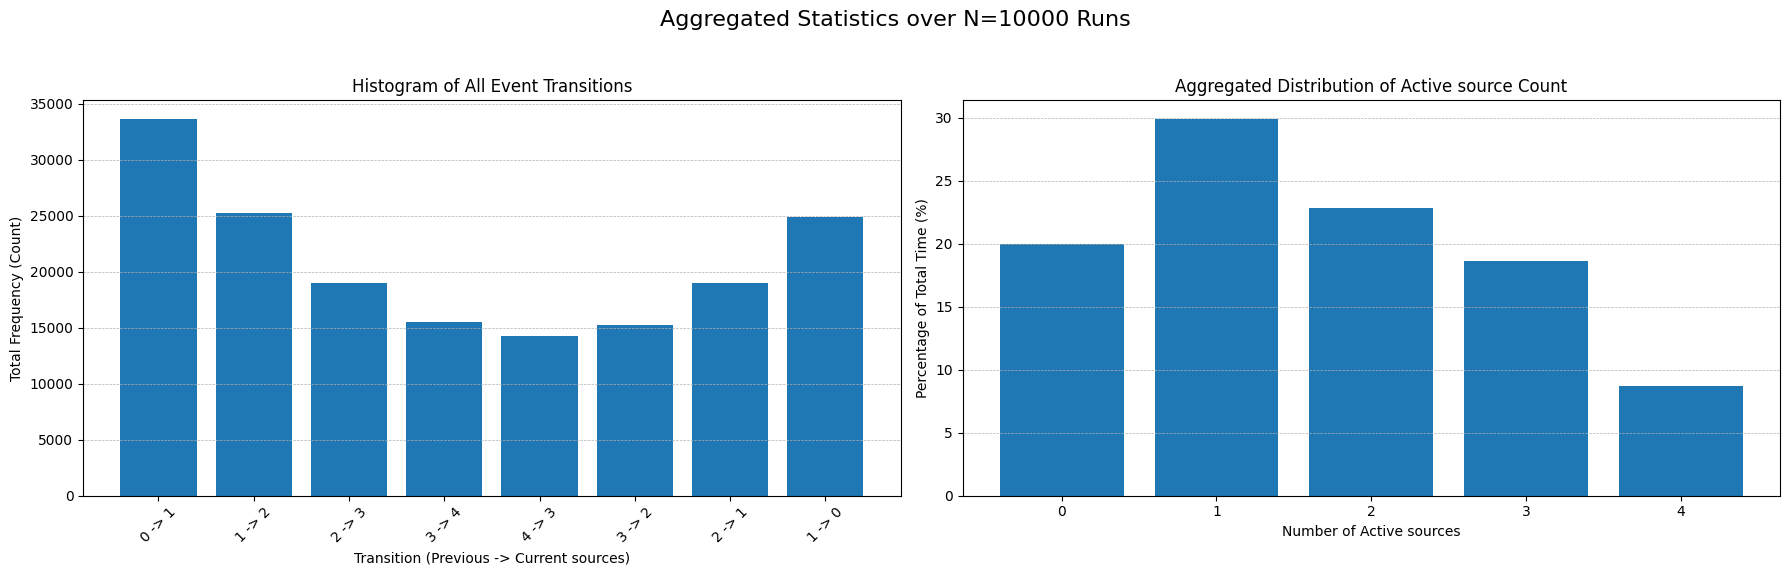

In [14]:
# 5. Run a large-scale simulation to verify the distributions
from collections import Counter
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- Parameters for the large-scale test ---
N = 10000
total_duration = 60.0
sampling_frequency = 100
max_sources = 4
time_between_events = (2.0, 5.0)
initial_noise_only_duration = (2.0, 5.0)
source_ids = [f"S{i}" for i in range(1, max_sources + 1)]

# --- Aggregators for statistics ---
total_transition_counts = Counter()
total_source_counts = torch.zeros(max_sources + 1, dtype=torch.int64)
total_time_steps = 0

print(f"Running simulation for {N} activation patterns...")

# --- Loop to generate patterns and aggregate statistics ---
for _ in range(N):
    # Generate the activation pattern
    activation_pattern = generate_activation_pattern(
        source_ids=source_ids,
        max_sources=max_sources,
        total_duration=total_duration,
        time_between_events=time_between_events,
        initial_noise_only_duration=initial_noise_only_duration,
    )

    # Convert the pattern to a time series
    time_series = convert_pattern_to_time_series(
        activation_pattern=activation_pattern,
        total_duration=total_duration,
        sampling_frequency=sampling_frequency,
    )

    # Aggregate transition statistics
    prev_num_sources = 0
    for event in activation_pattern:
        current_num_sources = event['num_sources']
        total_transition_counts[f"{prev_num_sources} -> {current_num_sources}"] += 1
        prev_num_sources = current_num_sources

    # Aggregate source number distribution
    total_source_counts += torch.bincount(time_series, minlength=max_sources + 1)
    total_time_steps += time_series.numel()

print("Simulation finished.")

# --- Calculate Final Distributions ---
# Sort transitions for plotting
activation_transitions = [f"{i} -> {i+1}" for i in range(max_sources)]
deactivation_transitions = [f"{i} -> {i-1}" for i in range(max_sources, 0, -1)]
custom_sort_order = activation_transitions + deactivation_transitions

sorted_transition_items = sorted(
    total_transition_counts.items(),
    key=lambda item: custom_sort_order.index(item[0]) if item[0] in custom_sort_order else -1
)

# Normalize source distribution
source_distribution = total_source_counts.float() / total_time_steps

# --- Print Statistics ---
print("\n--- Aggregated Event Transition Statistics ---")
for transition, count in sorted_transition_items:
    print(f"Transition {transition}: {count} occurrences")

print("\n--- Aggregated Source Number Distribution (over time) ---")
for i, percentage in enumerate(source_distribution):
    print(f"{i} active sources: {percentage:.2%} of the time")


# --- Plotting Histograms ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle(f'Aggregated Statistics over N={N} Runs', fontsize=16)

# Subplot 1: Histogram of event transitions
if sorted_transition_items:
    labels, values = zip(*sorted_transition_items)
    ax1.bar(labels, values)
else:
    labels, values = [], []
ax1.set_title("Histogram of All Event Transitions")
ax1.set_xlabel("Transition (Previous -> Current sources)")
ax1.set_ylabel("Total Frequency (Count)")
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', linestyle='--', linewidth=0.5)

# Subplot 2: Histogram of source number distribution
num_sources = np.arange(len(source_distribution))
ax2.bar(num_sources, source_distribution.numpy() * 100)
ax2.set_title("Aggregated Distribution of Active source Count")
ax2.set_xlabel("Number of Active sources")
ax2.set_ylabel("Percentage of Total Time (%)")
ax2.set_xticks(num_sources)
ax2.grid(axis='y', linestyle='--', linewidth=0.5)

plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()
